In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [13]:
# ==========================================
# 1. 설정 (Configuration)
# ==========================================
# [수정] 인코딩 코드로 만든 .pt 파일 경로
TEST_DATA_PATH = "C:/Users/user/Desktop/IDS_masters/small_CAN_MIRGU/validation_dataset.npz"

# [수정] 학습된 모델 가중치 파일 경로
MODEL_PATH = "C:/Users/user/Desktop/IDS_masters/seqids_causal_final.pth"

BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 라벨 이름 (결과 리포트용)
LABEL_NAME = {0: "Normal", 1: "DoS", 2: "Fuzzing", 3: "Replay", 4: "Spoofing"}
TARGET_NAMES = [LABEL_NAME[i] for i in range(5)]

In [14]:
class SeqWindowDataset(Dataset):
    def __init__(self, path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"❌ 데이터 파일이 없습니다: {path}")
            
        print(f"Loading dataset from {path}...")

        ext = os.path.splitext(path)[1].lower()

        if ext == ".npz":
            data_np = np.load(path)
            X_np = data_np["X"]
            y_np = data_np["y"]

            print(f"  ➤ npz keys: {list(data_np.keys())}")
            print(f"  ➤ X_np shape: {X_np.shape}, y_np shape: {y_np.shape}")
            print(f"  ➤ X_np dtype: {X_np.dtype}, y_np dtype: {y_np.dtype}")

            self.X = torch.tensor(X_np, dtype=torch.float32)  # (N, 9, 64)
            y_full = torch.tensor(y_np, dtype=torch.long)     # (N, 64)

            # 🔹 윈도우 레벨 라벨 계산
            window_labels = []
            for i in range(y_full.shape[0]):
                seq = y_full[i]           # (64,)
                non_zero = seq[seq != 0]  # 공격 라벨만 추출
                if len(non_zero) == 0:
                    window_labels.append(0)  # Normal
                else:
                    window_labels.append(int(non_zero[0].item()))  # 첫 번째 공격 라벨 사용

            self.y = torch.tensor(window_labels, dtype=torch.long)  # (N,)

        elif ext == ".pt":
            data = torch.load(path, map_location="cpu")
            self.X = data["X"].float()
            self.y = data["y"].long()
        else:
            raise ValueError(f"지원하지 않는 파일 확장자입니다: {ext}")

        print(f"✅ Data Loaded: X shape={self.X.shape}, y shape={self.y.shape}")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # X[idx]: (9,64), y[idx]: scalar(int)
        return self.X[idx], self.y[idx]


In [15]:
# ==========================================
# 3. 모델 구조 정의 (설계도)
# ==========================================
# ★ 학습 때 사용했던 모델 클래스와 동일해야 합니다!
class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super(CausalConv1d, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              padding=self.padding, dilation=dilation)

    def forward(self, x):
        x = self.conv(x)
        if self.padding != 0:
            x = x[:, :, :-self.padding]
        return x

class SeqIDS(nn.Module):
    def __init__(self, num_classes=5):
        super(SeqIDS, self).__init__()
        self.layer1 = CausalConv1d(9, 32, kernel_size=5)
        self.relu1 = nn.ReLU()
        self.layer2 = CausalConv1d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.classifier = nn.Conv1d(64, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        logits = self.classifier(x)  # (B, 5, 64)
        return logits




🚀 Device: cuda
Loading dataset from C:/Users/user/Desktop/IDS_masters/small_CAN_MIRGU/validation_dataset.npz...
  ➤ npz keys: ['X', 'y']
  ➤ X_np shape: (548692, 9, 64), y_np shape: (548692, 64)
  ➤ X_np dtype: float32, y_np dtype: int64
✅ Data Loaded: X shape=torch.Size([548692, 9, 64]), y shape=torch.Size([548692])
🚀 Loading model from C:/Users/user/Desktop/IDS_masters/seqids_causal_final.pth...
✅ Model weights loaded successfully.
🚀 Starting Inference...

📊 Final Evaluation Report
Accuracy        : 67.75%
Precision(macro): 0.7160
Recall(macro)   : 0.3080
F1(macro)       : 0.3350

=== Confusion Matrix ===
tensor([[347494,      0,     90,   1658,     52],
        [ 17752,  11835,    315,   4285,     77],
        [ 32665,      0,   6034,   1942,      0],
        [     0,      0,      0,      0,      0],
        [112475,      0,    128,   5506,   6384]], dtype=torch.int32)

=== Per-class (Attack) Accuracy ===
    Normal :  99.48%  (correct 347494/349294)
       DoS :  34.54%  (correct 1

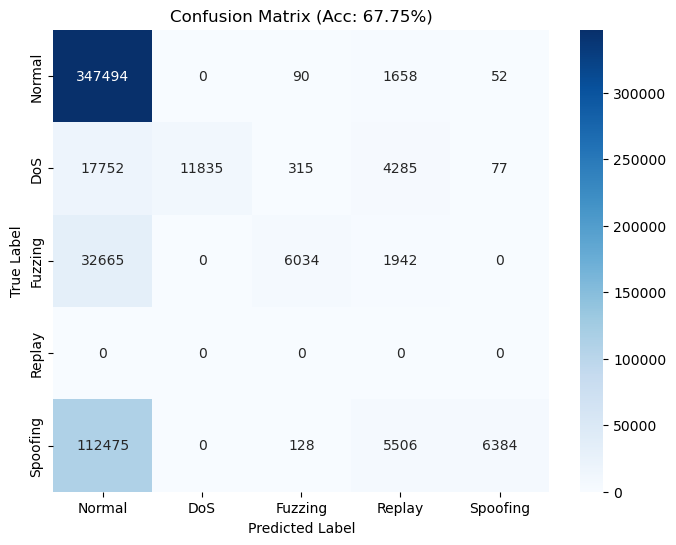

In [16]:
# ==========================================
# 4. 메인 평가 로직
# ==========================================
def main():
    print(f"🚀 Device: {DEVICE}")

    # 1. 데이터셋 & 데이터로더 준비
    # 인코딩 코드로 만든 .pt 파일 하나만 읽으면 됩니다 (X, y 포함됨)
    test_ds = SeqWindowDataset(TEST_DATA_PATH)
    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0 
    )

    # 2. 모델 준비 및 가중치 로드
    print(f"🚀 Loading model from {MODEL_PATH}...")
    model = SeqIDS(num_classes=5).to(DEVICE)

    
    if os.path.exists(MODEL_PATH):
        try:
            model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
            print("✅ Model weights loaded successfully.")
        except Exception as e:
            print(f"❌ Error loading weights: {e}")
            return
    else:
        print(f"❌ Model file not found at {MODEL_PATH}")
        return

    # 3. 평가 시작
    model.eval()

    correct = 0
    total = 0
    num_classes = 5

    conf_mat = torch.zeros(num_classes, num_classes)

    print("🚀 Starting Inference...")
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            # 모델 추론
            logits = model(inputs)  # (B, 5, 64)

            # Many-to-One: 마지막 타임스텝의 예측값 사용
            logits_last = logits[:, :, -1]        # (B, 5)
            pred = torch.argmax(logits_last, dim=1)  # (B,)

            # 정확도 누적
            total += labels.numel()
            correct += (pred == labels).sum().item()

            # 혼동 행렬 업데이트
            y_cpu = labels.detach().cpu()
            pred_cpu = pred.detach().cpu()
            
            for t, p in zip(y_cpu.view(-1), pred_cpu.view(-1)):
                conf_mat[t.long(), p.long()] += 1


    # 4. 지표 계산 및 출력
    accuracy = correct / total

    tp = conf_mat.diag()
    fp = conf_mat.sum(0) - tp
    fn = conf_mat.sum(1) - tp

    precision_per_class = tp / (tp + fp + 1e-12)
    recall_per_class    = tp / (tp + fn + 1e-12)
    f1_per_class        = 2 * precision_per_class * recall_per_class / (precision_per_class + recall_per_class + 1e-12)

    precision_macro = precision_per_class.mean().item()
    recall_macro    = recall_per_class.mean().item()
    f1_macro        = f1_per_class.mean().item()

    print("\n" + "="*50)
    print("📊 Final Evaluation Report")
    print("="*50)
    print(f"Accuracy        : {accuracy*100:.2f}%")
    print(f"Precision(macro): {precision_macro:.4f}")
    print(f"Recall(macro)   : {recall_macro:.4f}")
    print(f"F1(macro)       : {f1_macro:.4f}")
    
    print("\n=== Confusion Matrix ===")
    print(conf_mat.int())

    # 5. 클래스별 정확도 (Per-class Accuracy)
    row_sum = conf_mat.sum(dim=1)
    class_acc = tp / (row_sum + 1e-12)

    print("\n=== Per-class (Attack) Accuracy ===")
    for i in range(num_classes):
        n = int(row_sum[i].item())
        acc_i = 100.0 * class_acc[i].item()
        name = LABEL_NAME.get(i, f"Class_{i}")
        
        # 데이터가 없는 클래스는 0% 대신 '-' 표시 등 처리 가능
        print(f"{name:>10s} : {acc_i:6.2f}%  (correct {int(tp[i].item())}/{n})")

    # 6. 혼동 행렬 시각화
    # -> GPU에 있을 수도 있으니 cpu()로 옮기고, int로 변환해서 fmt='d'와 맞춰줌
    cm = conf_mat.cpu().numpy().astype(int)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix (Acc: {accuracy*100:.2f}%)')
    plt.show()

if __name__ == "__main__":
    main()